In [1]:
import pandas as pd
from pathlib import Path
BASE_DIR = Path.cwd().parent.parent.parent
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# 1) Load data
df = pd.read_csv(DATA_PROCESSED / "ml_dataset.csv", sep=";")

# 2) Define target (binary)
y = df["impact_high"].astype(int)

# 3) Define feature set
feature_cols = [
    "is_rockstar",
    "sentiment_negative",
    "market_return",
    "AR_event",
    "franchise_gta",
    "vix_level",
    "vix_30d_mean",
    "event_type_marketing",
    "event_type_negative",
    "event_type_release",
    "vix_regime_medium",
    "vix_regime_high",
]

X = df[feature_cols].copy()

# Safety: everything numeric
X = X.astype(float)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # keeps class balance
)

In [4]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "Neural Network (MLP)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(16, 8),
            activation="relu",
            alpha=0.01,
            max_iter=2000,
            random_state=42
        ))
    ]),
}


=== Logistic Regression ===
Accuracy: 0.6818181818181818
F1 score: 0.46153846153846156
              precision    recall  f1-score   support

           0      0.706     0.857     0.774        14
           1      0.600     0.375     0.462         8

    accuracy                          0.682        22
   macro avg      0.653     0.616     0.618        22
weighted avg      0.667     0.682     0.661        22



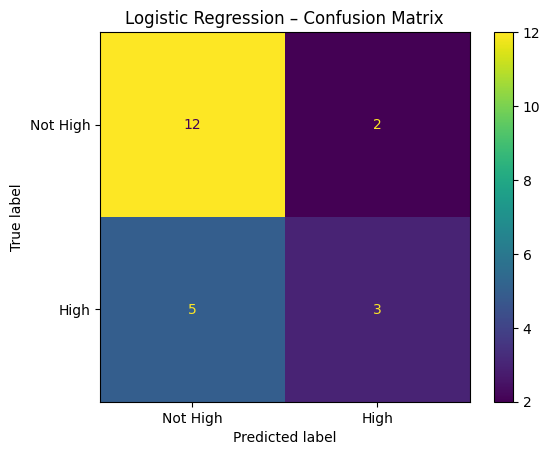


=== Random Forest ===
Accuracy: 0.5909090909090909
F1 score: 0.18181818181818182
              precision    recall  f1-score   support

           0      0.632     0.857     0.727        14
           1      0.333     0.125     0.182         8

    accuracy                          0.591        22
   macro avg      0.482     0.491     0.455        22
weighted avg      0.523     0.591     0.529        22



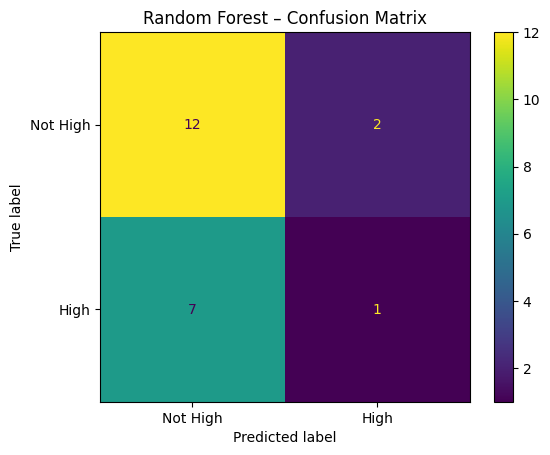


=== Gradient Boosting ===
Accuracy: 0.5454545454545454
F1 score: 0.16666666666666666
              precision    recall  f1-score   support

           0      0.611     0.786     0.688        14
           1      0.250     0.125     0.167         8

    accuracy                          0.545        22
   macro avg      0.431     0.455     0.427        22
weighted avg      0.480     0.545     0.498        22



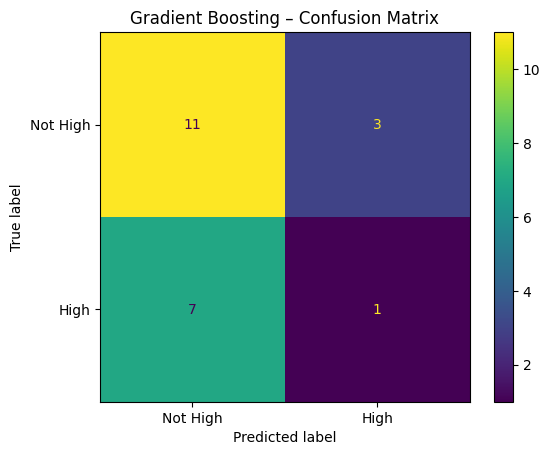


=== Neural Network (MLP) ===
Accuracy: 0.5909090909090909
F1 score: 0.47058823529411764
              precision    recall  f1-score   support

           0      0.692     0.643     0.667        14
           1      0.444     0.500     0.471         8

    accuracy                          0.591        22
   macro avg      0.568     0.571     0.569        22
weighted avg      0.602     0.591     0.595        22



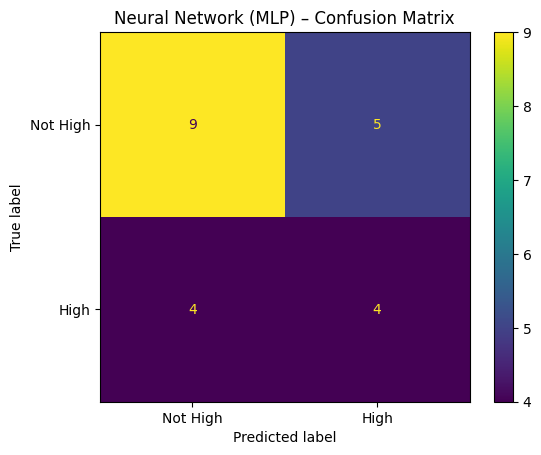


Summary:
                  Model  Accuracy        F1
0   Logistic Regression  0.681818  0.461538
1         Random Forest  0.590909  0.181818
2     Gradient Boosting  0.545455  0.166667
3  Neural Network (MLP)  0.590909  0.470588


In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    # Test metrics
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="binary")  # because 0/1

    results.append((name, acc, f1))
    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("F1 score:", f1)
    print(classification_report(y_test, y_pred, digits=3))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not High", "High"])
    disp.plot()
    plt.title(f"{name} – Confusion Matrix")
    plt.show()

# Summary table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])
print("\nSummary:")
print(results_df)

In [6]:
y3 = df["impact_label_num"].astype(int)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y3,
    test_size=0.3,
    random_state=42,
    stratify=y3
)

gb3 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb3.fit(X_train3, y_train3)

y_pred3 = gb3.predict(X_test3)
print("3-class accuracy:", accuracy_score(y_test3, y_pred3))
print("3-class F1 (macro):", f1_score(y_test3, y_pred3, average="macro"))
print(classification_report(y_test3, y_pred3, digits=3))

3-class accuracy: 0.3181818181818182
3-class F1 (macro): 0.25
              precision    recall  f1-score   support

           0      0.455     0.556     0.500         9
           1      0.000     0.000     0.000         5
           2      0.250     0.250     0.250         8

    accuracy                          0.318        22
   macro avg      0.235     0.269     0.250        22
weighted avg      0.277     0.318     0.295        22

